**HOUSE PRICE PREDICTOR. **

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

In [61]:
df = pd.read_csv('housing.csv')

In [62]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [63]:
df = df.dropna()
df = df[df['median_house_value']<500000]

df['rpm'] = df['total_rooms'] / df['households']
df['bpr'] = df['total_bedrooms'] / df['total_rooms']

x = df[[
    'median_income',
    'rpm',
    'bpr',
    'population',
    'households',
    'housing_median_age'
]]
y = df['median_house_value']

In [64]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [65]:
xtrain , xtest , ytrain , ytest = train_test_split(x,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

In [66]:
model = LinearRegression()
model.fit(xtrain,ytrain)

LinearRegression()

In [67]:
pred = model.predict(xtest)

In [70]:
mae = mean_absolute_error(ytest,pred)
r2 = r2_score(ytest,pred)
print('Mae:', mae)
print('r2:', r2)


Mae: 48872.69179207162
r2: 0.5618995963943612


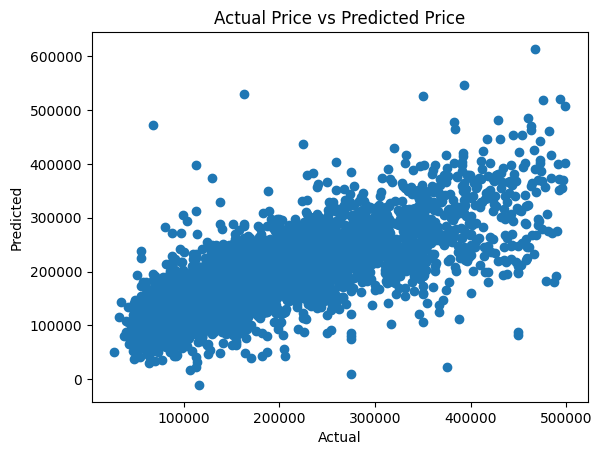

In [69]:
plt.scatter(ytest,pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual Price vs Predicted Price')
plt.show()